In [2]:
#Import in all important packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight



In [4]:
#Load the data 
#Set the train/test datasets
train = pd.read_csv("glp1_train.csv")
test = pd.read_csv("glp1_test.csv")

TARGET = "Coverage Bucket"
FEATURES = [c for c in train.columns if c != TARGET]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts().to_string()}\n")

Train: (1164, 37)  |  Test: (291, 37)
Target distribution (train):
Coverage Bucket
1    1042
0     122



In [5]:
# Fix class imbalance 
classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weight_dict}\n")

Class weights: {np.int64(0): np.float64(4.770491803278689), np.int64(1): np.float64(0.5585412667946257)}



In [6]:
# Train
dt = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=22
)

dt.fit(X_train, y_train)
print("✅ Model trained.\n")

✅ Model trained.



In [7]:
# Predictions

y_pred = dt.predict(X_test)
y_pred_prob = dt.predict_proba(X_test)[:, 1]

In [9]:
# Evaluate

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Bucket 0", "Bucket 1"]))

auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc:.4f}\n")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Bucket 0       0.51      0.87      0.64        30
    Bucket 1       0.98      0.90      0.94       261

    accuracy                           0.90       291
   macro avg       0.75      0.89      0.79       291
weighted avg       0.93      0.90      0.91       291

ROC-AUC Score: 0.8946



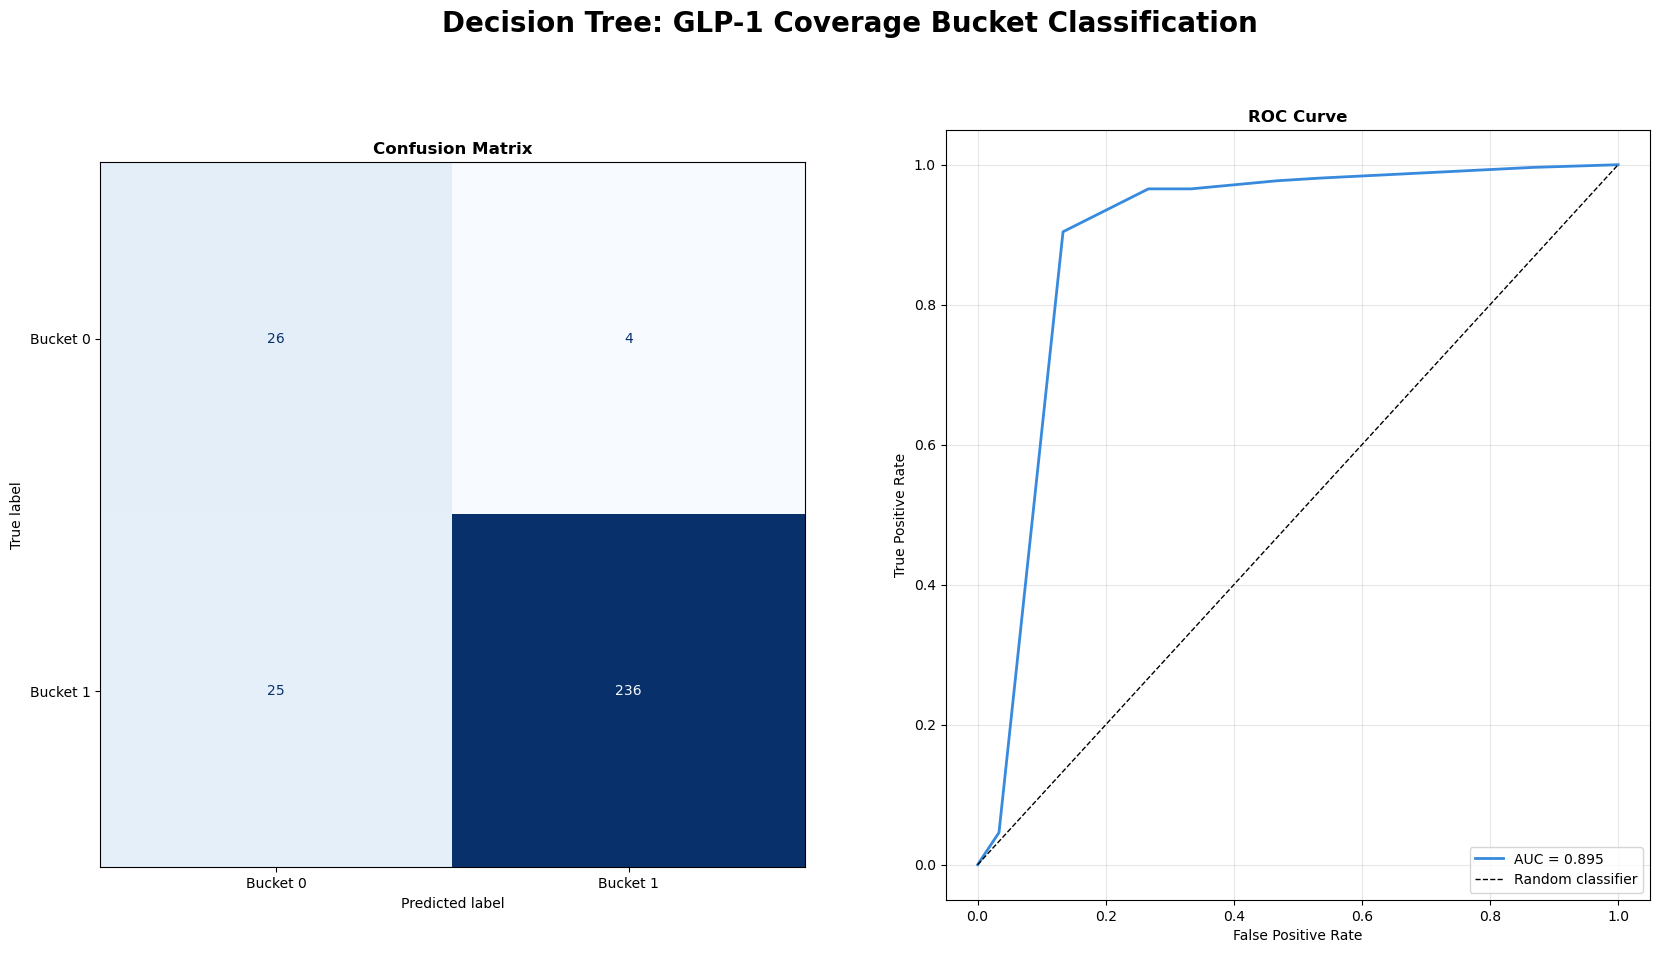

In [14]:
# Plotting

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Decision Tree: GLP-1 Coverage Bucket Classification",
             fontsize=20, fontweight="bold", y=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bucket 0", "Bucket 1"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].set_facecolor("white")
axes[1].grid(True, alpha=0.3)




In [15]:
# Summary Table

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Bucket 0)", "Precision (Bucket 1)",
               "Recall (Bucket 0)", "Recall (Bucket 1)",
               "F1 (Bucket 0)", "F1 (Bucket 1)", "ROC-AUC"],
    "Score": [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred, pos_label=0), 4),
        round(precision_score(y_test, y_pred, pos_label=1), 4),
        round(recall_score(y_test, y_pred, pos_label=0), 4),
        round(recall_score(y_test, y_pred, pos_label=1), 4),
        round(f1_score(y_test, y_pred, pos_label=0), 4),
        round(f1_score(y_test, y_pred, pos_label=1), 4),
        round(auc, 4),
    ]
})

print("\n" + "=" * 35)
print("SUMMARY TABLE")
print("=" * 35)
print(summary.to_string(index=False))


SUMMARY TABLE
              Metric  Score
            Accuracy 0.9003
Precision (Bucket 0) 0.5098
Precision (Bucket 1) 0.9833
   Recall (Bucket 0) 0.8667
   Recall (Bucket 1) 0.9042
       F1 (Bucket 0) 0.6420
       F1 (Bucket 1) 0.9421
             ROC-AUC 0.8946


In [16]:
# Top feature importance

print("\n" + "=" * 35)
print("TOP 10 FEATURE IMPORTANCES")
print("=" * 35)

top10_feat = pd.Series(dt.feature_importances_, index=FEATURES).nlargest(10)
for feat, score in top10_feat.items():
    print(f"  {feat:<35} {score:.4f}")

macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"\nMacro F1 Score: {macro_f1:.4f}")


TOP 10 FEATURE IMPORTANCES
  State_DE                            0.2538
  State_DC                            0.2491
  State_AZ                            0.2410
  State_IL                            0.1312
  Utilization Type_FFSU               0.0549
  Product Name_TRULICITY              0.0519
  Number of Prescriptions             0.0180
  Units Reimbursed                    0.0001
  Quarter_2                           0.0000
  Quarter_1                           0.0000

Macro F1 Score: 0.7920
